## DDIM inversion (initalise with MCPL pretrained)

In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch


from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler,StableDiffusionPipeline
from causal_modules.ddim_modules import *
size = 256

image_transforms = transforms.Compose(
        [
            transforms.CenterCrop(150),
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
        )
original_transforms = transforms.Compose(
        [
            transforms.CenterCrop(150),
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
        ]
        )

conditioning_image_transforms = transforms.Compose(
            [
                transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.ToTensor(),
                #transforms.Normalize([0.5], [0.5]),
            ]
        )
        

In [3]:
'''Load pipeline'''


base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"
'''cond_img'''
#controlnet_path = "../logs/logs_celeA_complex_all/2025-05-20T14-44-34-controlnet_nomcplgeneration_image/controlnet-steps-10000.safetensors"
#mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-05-20T14-44-34-controlnet_nomcplgeneration_image/learned_embeds-steps-10000.safetensors"
# controlnet_path = "../logs/logs_celeA_complex_all/2025-05-20T14-44-34-controlnet_nomcplgeneration_image/controlnet-steps-100000.safetensors"
# mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-05-20T14-44-34-controlnet_nomcplgeneration_image/learned_embeds-steps-100000.safetensors"
'''cond_text'''
#controlnet_path = "../logs/logs_celeA_complex_all/2025-04-21T08-46-52-controlnet_textcond_nocontrastgeneration_text_global_after/controlnet-steps-100000.safetensors"
#mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-04-21T08-46-52-controlnet_textcond_nocontrastgeneration_text_global_after/learned_embeds-steps-100000.safetensors"
'''cond_text_contrastive'''
#controlnet_path = "../logs/logs_celeA_complex_all/2025-04-17T20-43-28-controlnet_textcond_constrastivegeneration_text_global_after/controlnet-steps-100000.safetensors"
#mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-04-17T20-43-28-controlnet_textcond_constrastivegeneration_text_global_after/learned_embeds-steps-100000.safetensors"
controlnet_path = "../logs/logs_celeA_complex_all/2025-04-23T17-05-57-controlnet_textcond_constrastivegeneration_text_global_after/controlnet-steps-200000.safetensors"
mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-04-23T17-05-57-controlnet_textcond_constrastivegeneration_text_global_after/learned_embeds-steps-200000.safetensors"#

'''different prompt string'''
controlnet_path = "../logs/logs_celeA_complex_all/2025-10-06T16-21-07-controlnet_textcond_constrastive_shortstringgeneration_text_global_after/controlnet-steps-200000.safetensors"
mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-10-06T16-21-07-controlnet_textcond_constrastive_shortstringgeneration_text_global_after/learned_embeds-steps-200000.safetensors"#

#controlnet_path = "../logs/logs_pendulum_all/2025-04-02T10-49-18-controlnet_textcondgeneration_text_global_after/controlnet-steps-30000.safetensors"
#mcpl_embedding_path = None
causalnet_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/logs_celeA_complex_all/2025-04-23T21-11-19-causalnet_pretrain/best_model.pt'
device = torch.device("cuda")
controlnet = Causal_ControlNetModel.from_pretrained(controlnet_path,torch_dtype=torch.float32)
if causalnet_path is not None:
    print('load pretrained causalnet weights')
    controlnet.controlnet_cond_embedding.load_state_dict(torch.load(causalnet_path,weights_only=True))

A_matrix = torch.tensor([[0, 0, 1,1], [0, 0, 1,1], [0, 0, 0,0], [0, 0, 0,0]],dtype=torch.float32).to(device)
controlnet.controlnet_cond_embedding.update_mask(A_matrix)
controlnet.eval()
print('training_mode', controlnet.task_cond)
# Load mcpl embedding
#prompt = "a people photo of young and female and beard and bald"
prompt = 'an image of @ * & !'
#prompt = '@ * & !'
presudo_words= '@,*,&,!'
#presudo_words = 'young,female,beard,bald'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True
if 'image' in controlnet.task_cond:
    embed_control_manager_bool = False
text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)

pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
    base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
)
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
pipe.scheduler = DDIMScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", clip_sample=False, set_alpha_to_one=False)

pipe.safety_checker = None
pipe.requires_safety_checker = False
#pipe.load_mcpl_inversion(mcpl_embedding_path)


# memory optimization.
pipe = pipe.to(device)

Skipping initialization on meta device.
Skipping initialization on meta device.
load pretrained causalnet weights
training_mode generation_text_global_after


/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loaded textual inversion embedding for 256.
Loaded textual inversion embedding for 261.
Loaded textual inversion embedding for 265.
Loaded textual inversion embedding for 287.
load embedding control


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f

In [5]:
'''from training set'''
import random
import pandas as pd
from torchvision.datasets import CelebA
def dataset_load_path(data_root,dataset,split='train'):
    data_dir = data_root
    data = CelebA(root=data_dir, split=split, transform=None, download=False)
    num_images = len(data)
    if 'simple' in dataset:
        selected_item = ['Smiling','Eyeglasses']
    
    elif 'complex' in dataset:
        selected_item = ['Young','Male','No_Beard','Bald']
    else:
        AssertionError('no such {} dataset'.format(dataset))
    attribute_ids = [data.attr_names.index(attr) for attr in selected_item]
    metrics = {attr: torch.as_tensor(data.attr[:, attr_id], dtype=torch.float32) for attr, attr_id in zip(selected_item, attribute_ids)}

    attrs = torch.cat([metrics[attr].unsqueeze(1)
                            for attr in selected_item], dim=1)
    imglabel= attrs
    possible_values = {attr: torch.unique(values, dim=0) for attr, values in metrics.items()}
    
    img_id = random.randint(0,num_images)
    return data,imglabel,num_images

#img_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test/a_-1_128_4_12.png'
data,imglabel,num_images = dataset_load_path(data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/datasets/',dataset=controlnet.dataset,split='valid')

In [ ]:
import torch
import random
from torchvision import transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# imglabel: [16200, 4] tensor
# data: indexable dataset where data[i] -> (image, label_or_meta)

# 1) Find indices where label[:,1]==0 and label[:,2]==0
mask = (imglabel[:, 1] == 0) & (imglabel[:, 3] == 1)
idxs = mask.nonzero(as_tuple=False).squeeze(1)  # shape: [num_matches]

print(f"Matched {idxs.numel()} images")

Matched 1 images


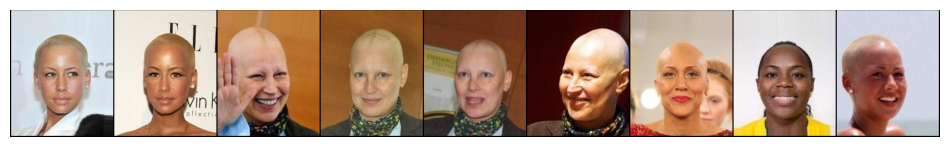

In [35]:
# pick first 10 indices
select_range = idxs[:10]

# convert each PIL image to tensor in [0,1]
to_tensor = transforms.ToTensor()
select_imgs = [to_tensor(data[i][0]) for i in select_range]

# stack into a batch
imgs_tensor = torch.stack(select_imgs, dim=0)  # [B,C,H,W]

# make grid
grid = make_grid(imgs_tensor, nrow=len(select_range))

# show
plt.figure(figsize=(12, 6))
plt.axis("off")
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.show()

tensor([[1., 1., 1., 0.]])


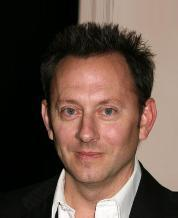

In [5]:
# paper image id (190,8385,2457,2184,3627,5694)
# female (8385,3393,6942)
img_id = random.randint(0,num_images)
img_id=190
img,label = data[img_id][0],imglabel[img_id].unsqueeze(0)
print(label)
img

50it [00:05,  9.99it/s]


save imgs in ./intervention_variable0.png


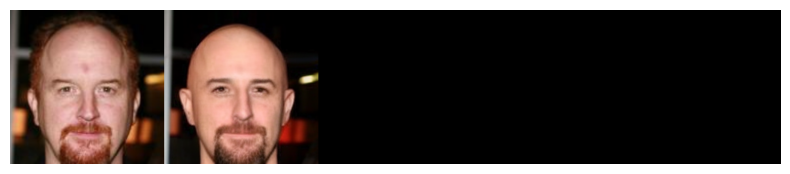

In [45]:
# Prompt2Prompt
from copy import deepcopy
image = img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image) 

# PNP+direct inversion
# do intervention 
inter_value = 1- label.clone().squeeze()
# if female, do the OOD editing
if int(label.squeeze()[1].item()) == 0:
    inter_value[2]=-1.0
#inter_value[3]=2.0

inter_value[0] =1

# backup_pipe = deepcopy(pipe)
set_guidance_scale  = 3.0
num_steps = 50      
s_step = 0
invert_guidance_scale=1.0
# False use the normal DDIM 
blend_word = False
# start_blend=0.2, th=(.3, .3)
image_lists = [np.asarray(original_img)]
#final_im,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, image.unsqueeze(0).repeat(4, 1, 1, 1),text_label,prompt,presudo_list,num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,set_guidance_scale  = set_guidance_scale,intervention_indx=1,intervention_values=inter_value[1],return_PIL=True,blend_word=blend_word)
for inter_id in range(0,1,1):
    images = []
    #inter_value  = -1   
    s_step = 0
    if inter_id in [0]:
        blend_params = {'start_blend':0.0,'th':(0.3,0.5)}
        cross_replace_steps,self_replace_steps = 0.0,0.0
    if inter_id in [1]:
        blend_params = {'start_blend':0.0,'th':(0.3,0.5)}
        cross_replace_steps,self_replace_steps = 0.0,0.0
    elif inter_id in [2]:
        blend_params = {'start_blend':0.0,'th':(0.1,0.7)}
        cross_replace_steps,self_replace_steps = 0.0,0.0
    elif inter_id in [3]:
        blend_params = {'start_blend':0.0,'th':(0.5,0.15)}
        cross_replace_steps,self_replace_steps = 0.0,0.0
    interved_image,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, image.unsqueeze(0),
                                                        label.clone(),prompt,presudo_list,
                                                        num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,
                                                        set_guidance_scale  = set_guidance_scale,intervention_indx=inter_id,
                                                        intervention_values=inter_value[inter_id],return_PIL=True,
                                                        blend_word=blend_word,blend_params=blend_params,
                                                        disentangle=True,
                                                        cross_replace_steps=cross_replace_steps,self_replace_steps=self_replace_steps,)
    image_lists.append(np.asarray(interved_image[-1]))
          
    
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,5),save_path)
print('save imgs in {}'.format(save_path))



In [ ]:
import os
save_path = '../outputs/datasets/test/{}'.format(img_id)
os.makedirs(save_path, exist_ok=True)

# Resize and save each image
for i, img in enumerate(tqdm(image_lists[1:], desc="Resizing and saving")):
    # Convert to PIL image
    pil_img = Image.fromarray(img)
    # pil_img.save(os.path.join(save_path, f"{i}.png"))
    # Resize to 64×64
    resized_img = pil_img.resize((64, 64), Image.BICUBIC)
    resized_img = resized_img.resize((207, 207), Image.BICUBIC)
    # Save as PNG
    resized_img.save(os.path.join(save_path, f"{i}.png"))


Resizing and saving:   0%|          | 0/4 [00:00<?, ?it/s]

Resizing and saving: 100%|██████████| 4/4 [00:00<00:00, 25.80it/s]


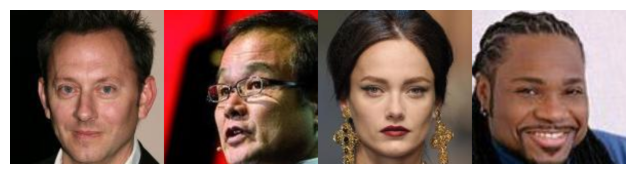

In [6]:
from copy import deepcopy

ori_imgs,img_list, label_list =[], [],[]
for i in range(190,194,1):
    image = data[i][0]
    if not image.mode == "RGB":
        image = image.convert("RGB")
    original_img = original_transforms(image)
    image = image_transforms(image) 
    ori_imgs.append(original_img)
    img_list.append(image)
    label_list.append(imglabel[i])

img_tensor = torch.stack(img_list, dim=0)      # -> [B,C,H,W]

# Stack labels: if labels are scalars or 1D vectors
label = torch.stack(label_list, dim=0)

inter_value = 1- label.clone()
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(0))
save_images_grid([ori_imgs],(1,len(img_tensor)),save_path)


50it [00:14,  3.42it/s]


save imgs in ./intervention_variable2.png


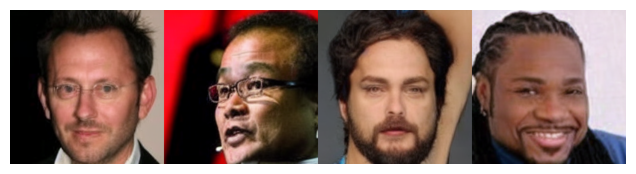

In [7]:

# backup_pipe = deepcopy(pipe)
set_guidance_scale  = 3.0
num_steps = 50      
s_step = 0
invert_guidance_scale=1.0
inter_id = 2
if int(inter_id)==2:
    row_index = torch.where(inter_value[:, 1] == 0)[0]
    inter_value[row_index, inter_id] = -1

# False use the normal DDIM 
blend_word = True
# start_blend=0.2, th=(.3, .3)
image_lists = []
#final_im,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, image.unsqueeze(0).repeat(4, 1, 1, 1),text_label,prompt,presudo_list,num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,set_guidance_scale  = set_guidance_scale,intervention_indx=1,intervention_values=inter_value[1],return_PIL=True,blend_word=blend_word)

images = []
#inter_value  = -1   
s_step = 0
if inter_id in [0]:
    blend_params = {'start_blend':0.0,'th':(0.3,0.3)}
    cross_replace_steps,self_replace_steps = 0.1,0.1
if inter_id in [1]:
    blend_params = {'start_blend':0.0,'th':(0.3,0.3)}
    cross_replace_steps,self_replace_steps = 0.2,0.2
elif inter_id in [2]:
    blend_params = {'start_blend':0.0,'th':(0.3,0.8)}
    cross_replace_steps,self_replace_steps = 0.1,0.1
elif inter_id in [3]:
    blend_params = {'start_blend':0.0,'th':(0.45,0.8)}
    cross_replace_steps,self_replace_steps = 0.1,0.1
interved_image,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, img_tensor,
                                                    label.clone(),prompt,presudo_list,
                                                    num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,
                                                    set_guidance_scale  = set_guidance_scale,intervention_indx=inter_id,
                                                    intervention_values=inter_value[:,inter_id],return_PIL=True,
                                                    blend_word=blend_word,blend_params=blend_params,
                                                    disentangle=False,
                                                    cross_replace_steps=cross_replace_steps,self_replace_steps=self_replace_steps,)        

image_lists.extend(interved_image)
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,len(img_tensor)),save_path)
print('save imgs in {}'.format(save_path))





In [51]:
inter_value

tensor([[0., 0., 0., 1.],
        [1., 0., 0., 1.],
        [0., 1., 0., 1.],
        [1., 0., 1., 1.]])

In [6]:
# Null textual inversion
from copy import deepcopy
image = img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image) 

# backup_pipe = deepcopy(pipe)
set_guidance_scale  = 1.0
num_steps = 50      
s_step = 0
invert_guidance_scale=1.0
# False use the normal DDIM 
null_optimization = False
final_im,inverted_latents,_,uncond_embeddings = ddim_editing(pipe, image.unsqueeze(0),label.clone(),prompt,num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,set_guidance_scale  = set_guidance_scale,intervention_indx=None,intervention_values=None,return_PIL=True,null_optimization=null_optimization)
        
to_pil =  transforms.ToPILImage()
save_images_grid([[original_img, final_im[0]]],(1,2),None)


  0%|          | 0/49 [00:00<?, ?it/s]


RuntimeError: The size of tensor a (16) must match the size of tensor b (4) at non-singleton dimension 0

100%|██████████| 49/49 [00:03<00:00, 12.60it/s]


save imgs in ./intervention_variable3.png


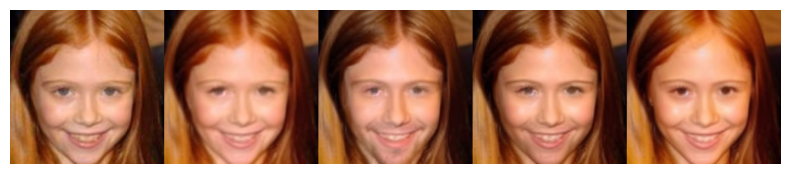

In [9]:
from causal_modules import ddim_modules
import importlib
importlib.reload(ddim_modules)
from copy import deepcopy
# PNP+direct inversion
# do intervention 
inter_value = 1- label.clone().squeeze()
# if female, do the OOD editing
if int(label.squeeze()[1].item()) == 0:
    inter_value[2]=-1.0
#inter_value[3]=1.5
# Do intervention
image_lists = [np.asarray(original_img)]
pnp = ddim_modules.PNP(deepcopy(pipe),num_steps,device=device)
for inter_id in range(0,4,1):
    images = []
    #inter_value  = -1   
    s_step = 0
    
    interved_image,causal_cond = pnp.run_pnp(inverted_latents,
                prompt,
                start_step=s_step,
                guidance_scale=3.5,
                num_inference_steps=num_steps-1,
                num_images_per_prompt=1,
                negative_prompt="",
                intervention_indx=inter_id,
                intervention_values=inter_value[inter_id],
                label=label.clone(),
                return_PIL = True,
                disentangle= False,
                pnp_f_t = 0.8,
                pnp_attn_t = 0.5,
    )
    #print(causal_cond)
    image_lists.append(np.asarray(interved_image[-1]))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,5),save_path)
print('save imgs in {}'.format(save_path))
del pnp.pipe

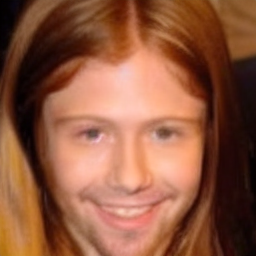

In [10]:
Image.fromarray(image_lists[2])

100%|██████████| 49/49 [00:04<00:00, 11.45it/s]

save imgs in ./intervention_variable3.png


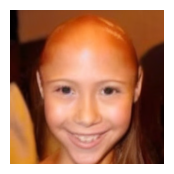

In [30]:
# do intervention (beard, manual seed 10, start from -1, gs lower , more obvious the OOD feature)
inter_id=3
range_len=1
inter_value = torch.from_numpy(np.linspace(0, 1.0, num=range_len))
image_lists = []
#inter_value  = -1   
s_step = 0
pnp = ddim_modules.PNP(deepcopy(pipe),num_steps,device=device)
for i in range(0,range_len,1):
    #inter_value  = -1   
    s_step = 0
    
    interved_image,causal_cond = pnp.run_pnp(inverted_latents,
                prompt,
                start_step=s_step,
                guidance_scale=2.5,
                num_inference_steps=num_steps-1,
                num_images_per_prompt=1,
                negative_prompt="",
                intervention_indx=inter_id,
                intervention_values=1.0,
                label=label.clone(),
                return_PIL = True,
                disentangle= False,
                pnp_f_t = 0.25,
                pnp_attn_t = 0.3,
    )
    #print(causal_cond)
    image_lists.append(np.asarray(interved_image[-1]))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,range_len),save_path)
print('save imgs in {}'.format(save_path))
del pnp.pipe


100%|██████████| 49/49 [00:04<00:00, 11.47it/s]


save imgs in ./intervention_variable1.png


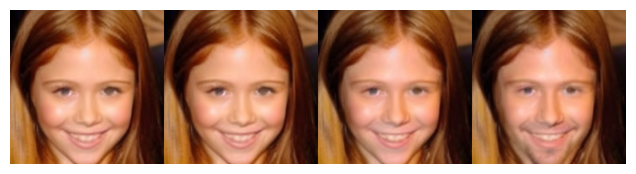

In [35]:
# do intervention (beard, manual seed 10, start from -1, gs lower , more obvious the OOD feature)
inter_id=1
range_len=4
inter_value = torch.from_numpy(np.linspace(0, 1, num=range_len))
image_lists = []
#inter_value  = -1   
s_step = 0
pnp = ddim_modules.PNP(deepcopy(pipe),num_steps,device=device)
for i in range(0,range_len,1):
    #inter_value  = -1   
    s_step = 0
    
    interved_image,causal_cond = pnp.run_pnp(inverted_latents,
                prompt,
                start_step=s_step,
                guidance_scale=3.5,
                num_inference_steps=num_steps-1,
                num_images_per_prompt=1,
                negative_prompt="",
                intervention_indx=inter_id,
                intervention_values=inter_value[i],
                label=label.clone(),
                return_PIL = True,
                disentangle= False,
                pnp_f_t = 0.8,
                pnp_attn_t = 0.5,
    )
    #print(causal_cond)
    image_lists.append(np.asarray(interved_image[-1]))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,range_len),save_path)
print('save imgs in {}'.format(save_path))
del pnp.pipe


In [11]:
len(image_lists)

11

In [11]:
for inter_id in range(0,4,1):
    images = []
    #inter_value  = -1   
    s_step = 0
    
    interved_image,causal_cond = pnp.run_pnp(inverted_latents,
                prompt,
                start_step=s_step,
                guidance_scale=5.5,
                num_inference_steps=num_steps-1,
                num_images_per_prompt=1,
                negative_prompt="",
                intervention_indx=inter_id,
                intervention_values=inter_value[inter_id],
                label=label.clone(),
                return_PIL = True,
                disentangle= True,
                pnp_f_t = 0.8,
                pnp_attn_t = 0.5,
    )
    #print(causal_cond)
    image_lists.append(np.asarray(interved_image[-1]))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,5),save_path)
print('save imgs in {}'.format(save_path))
del pnp.pipe

NameError: name 'pnp' is not defined

100%|██████████| 50/50 [00:03<00:00, 16.57it/s]


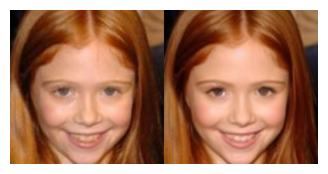

In [7]:
# Null textual inversion
image = img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image) 

set_guidance_scale  = 2.5
invert_guidance_scale = 1.0
num_steps = 50
s_step = 0
# False use the normal DDIM 
null_optimization = False
final_im,inverted_latents,_,uncond_embeddings = ddim_editing(pipe, image.unsqueeze(0),label.clone(),prompt,num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,set_guidance_scale  = set_guidance_scale,intervention_indx=None,intervention_values=None,return_PIL=True,null_optimization=null_optimization)
        
to_pil =  transforms.ToPILImage()
save_images_grid([[original_img, final_im[0]]],(1,2),None)

In [21]:
# lb  = LocalBlend(prompts=[prompt,prompt],words=['!','!'],tokenizer=pipe.tokenizer,xt_shape=inverted_latents[0].shape[2:],start_blend=0.2,th=(.3, .3))

# controller = AttentionControlEdit_blend(lb)
# controller.reset()

In [15]:
# NTI
# do intervention 
inter_value = 1- label.clone().squeeze()
# if female, do the OOD editing
if int(label.squeeze()[1].item()) == 0:
    inter_value[2]=-1.0
#inter_value[3]=0.9
# Do intervention
image_lists = [np.asarray(original_img)]
for inter_id in range(0,4,1):
    images = []
    #inter_value  = -1   
    s_step = 0
    interved_image,causal_cond = sample(
        pipe,
        prompt,
        start_step=s_step,
        start_latents=inverted_latents[-(s_step + 1)].clone(),
        guidance_scale=3.0,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=inter_id,
        intervention_values=inter_value[inter_id],
        label=label.clone(),
        return_PIL = True,
        disentangle= True,
        uncond_embeddings=uncond_embeddings,
        controller=None
    )
    #print(causal_cond)
    image_lists.append(np.asarray(interved_image[0]))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,5),save_path)
print('save imgs in {}'.format(save_path))

  0%|          | 0/50 [00:00<?, ?it/s]


RuntimeError: Given groups=1, weight of size [320, 4, 3, 3], expected input[1, 8, 32, 32] to have 4 channels, but got 8 channels instead

100%|██████████| 50/50 [00:02<00:00, 20.35it/s]


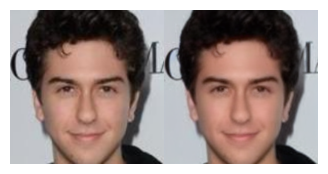

In [16]:
## DDIM
image = img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image) 

set_guidance_scale  = 1.0
num_steps = 50
s_step = 0
# False use the normal DDIM 
null_optimization = False
final_im,inverted_latents,_,n = ddim_editing(pipe, image.unsqueeze(0),label.clone(),prompt,num_steps = num_steps,invert_guidance_scale=1.0,set_guidance_scale  = set_guidance_scale,intervention_indx=None,intervention_values=None,return_PIL=True,null_optimization=null_optimization)
        
to_pil =  transforms.ToPILImage()
save_images_grid([[original_img, final_im[0]]],(1,2),None)

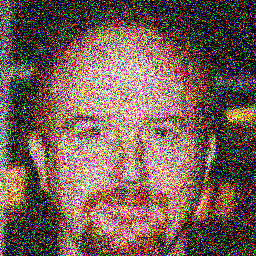

In [ ]:
# from PIL import Image
# import numpy as np

# def add_gaussian_noise_pil(img: Image.Image, noise_level_percent: float = 5.0) -> Image.Image:
#     """
#     Add Gaussian noise to a PIL image.

#     Parameters:
#     - img: PIL.Image, input image (grayscale or RGB)
#     - noise_level_percent: percentage of noise relative to 255 (e.g., 5 means std = 12.75)

#     Returns:
#     - PIL.Image with noise added
#     """
#     img_np = np.array(img).astype(np.float32)
#     std_dev = 255 * (noise_level_percent / 100.0)

#     noise = np.random.normal(loc=0.0, scale=std_dev, size=img_np.shape)

#     noisy_img = img_np + noise
#     noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

#     return Image.fromarray(noisy_img)

# noisy_img = add_gaussian_noise_pil(original_img, noise_level_percent=40)
# noisy_img


100%|██████████| 50/50 [00:03<00:00, 16.66it/s]


save imgs in ./intervention_variable3.png


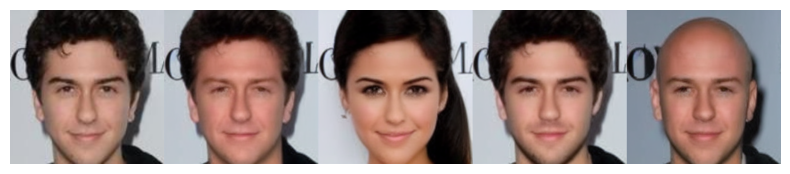

In [17]:
# do intervention 
use_DSCM_labels = False
if use_DSCM_labels:
    
else:
    inter_value = 1- label.clone().squeeze()
    # if female, do the OOD editing
    if int(label.squeeze()[1].item()) == 0:
        inter_value[2]=-1.0
#inter_value[3]=1.0
# Do intervention



image_lists = [np.asarray(original_img)]
for inter_id in range(0,4,1):
    images = []
    #inter_value  = -1   
    s_step = 0
    interved_image,causal_cond = sample(
        pipe,
        prompt,
        start_step=s_step,
        start_latents=inverted_latents[-(s_step + 1)].clone(),
        guidance_scale=3.0,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=inter_id,
        intervention_values=inter_value[inter_id],
        label=label.clone(),
        return_PIL = True,
        disentangle= True,
        uncond_embeddings=None,
    )
    #print(causal_cond)
    image_lists.append(np.asarray(interved_image[0]))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,5),save_path)
print('save imgs in {}'.format(save_path))

100%|██████████| 50/50 [00:03<00:00, 14.96it/s]


save imgs in ./intervention_variable2.png


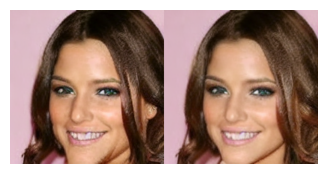

In [16]:
# do intervention
range_len=2
inter_value = torch.from_numpy(np.linspace(-1, 0, num=range_len))
# Do intervention
image_lists = []

generator = torch.manual_seed(5)
noise = torch.randn(1, 4, 32, 32, generator=generator)
fixed_noise =noise*pipe.scheduler.init_noise_sigma

for inter_id in range(2,3,1):
    images = []
    #inter_value  = -1   
    s_step = 0

    for j in range(0,range_len,1):
        interved_image,causal_cond = sample(
            pipe,
            prompt,
            start_step=s_step,
            start_latents = fixed_noise,
            #start_latents=inverted_latents[-(s_step + 1)].clone(),
            guidance_scale=3.0,
            num_inference_steps=num_steps,
            num_images_per_prompt=1,
            negative_prompt=None,
            device=device,
            controlnet_image=None,
            intervention_indx=inter_id,
            intervention_values=inter_value[j].unsqueeze(0),
            label=label.clone(),
            return_PIL = True,
            disentangle= True,
        )
        #print(causal_cond)
        image_lists.append(np.asarray(interved_image[0]))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,range_len),save_path)
print('save imgs in {}'.format(save_path))

In [7]:
import os
save_path = '../outputs/datasets/test/{}'.format(img_id)
os.makedirs(save_path, exist_ok=True)

# Resize and save each image
for i, img in enumerate(tqdm(image_lists, desc="Resizing and saving")):
    # Convert to PIL image
    pil_img = Image.fromarray(img)
    # pil_img.save(os.path.join(save_path, f"{i}.png"))
    # Resize to 64×64
    resized_img = pil_img.resize((64, 64), Image.BICUBIC)
    resized_img = resized_img.resize((207, 207), Image.BICUBIC)
    # Save as PNG
    resized_img.save(os.path.join(save_path, f"{i}.png"))


Resizing and saving: 100%|██████████| 4/4 [00:00<00:00, 30.00it/s]


In [6]:
import torch
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import os
import cv2

def find_top5_image_ids_batch(data, selected_img_dir, device='cuda'):
    # 加载所有要比对的输入图片
    selected_imgs = []
    img_names = []
    
    transform_input = transforms.Compose([
        transforms.Resize((64, 64)),    # Resize到64x64
        transforms.ToTensor(),          # (C,H,W)，范围[0,1]
    ])
    
    for img_name in sorted(os.listdir(selected_img_dir)):
        img_path = os.path.join(selected_img_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Cannot read image {img_path}, skip.")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        input_img = Image.fromarray(img)
        input_tensor = transform_input(input_img)
        selected_imgs.append(input_tensor)
        img_names.append(img_name)
    print(img_names)
    # 把选中图片堆成一个 batch
    input_batch = torch.stack(selected_imgs).to(device)  # (N,C,H,W)

    # 加载CelebA所有图，统一处理成 batch
    celebA_tensors = []
    transform_celeba = transforms.Compose([
        transforms.CenterCrop(150),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
    
    for idx in tqdm(range(len(data)), desc="Loading CelebA"):
        celebA_img, _ = data[idx]
        celebA_img = transform_celeba(celebA_img)
        celebA_tensors.append(celebA_img)
    
    celebA_batch = torch.stack(celebA_tensors).to(device)  # (M,C,H,W)

    # 计算每一张输入图片到CelebA所有图的距离
    results = {}
    for i, input_tensor in enumerate(input_batch):
        input_expand = input_tensor.unsqueeze(0).expand(celebA_batch.size(0), -1, -1, -1)
        diff = celebA_batch - input_expand  # (M,C,H,W)
        dists = (diff ** 2).sum(dim=(1,2,3)).sqrt()  # 正确地计算batch-wise L2距离
        top5_dist, top5_idx = torch.topk(dists, k=5, largest=False)

        results[img_names[i]] = list(zip(top5_idx.tolist(), top5_dist.tolist()))
    
    return results

selected_img_dir = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/test/"
results = find_top5_image_ids_batch(data, selected_img_dir)

for img_name, top5 in results.items():
    print(f"\nImage: {img_name}")
    for rank, (idx, dist) in enumerate(top5):
        print(f"  Top-{rank+1}: Image ID {idx}, Distance {dist:.4f}")


['Picture1.png']


Loading CelebA: 100%|██████████| 19867/19867 [00:31<00:00, 634.50it/s]



Image: Picture1.png
  Top-1: Image ID 23, Distance 8.7381
  Top-2: Image ID 1072, Distance 17.7960
  Top-3: Image ID 19404, Distance 17.9033
  Top-4: Image ID 7147, Distance 18.6170
  Top-5: Image ID 8184, Distance 18.6403


In [21]:
import cv2

img = cv2.imread('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/celeA_selected_images/1.png')
img.shape

libpng warning: iCCP: CRC error


(207, 207, 3)

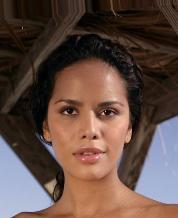

In [7]:

data[23][0]

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:03<00:00, 14.87it/s]


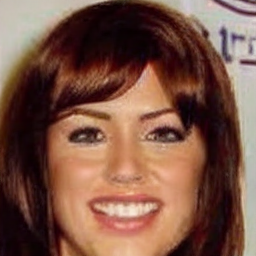

In [51]:
# try replace word
#prompt =  'orange @ and red * and black & and black !'
new_prompt = 'a human of @ and * and & and !'
input_ids = tokenizer(new_prompt,
                        padding="max_length",
                        truncation=True,
                        max_length=tokenizer.model_max_length,
                        return_tensors="pt",
                    ).input_ids[0].to(device)

if input_ids.dim() ==1:
    input_ids=input_ids.unsqueeze(0)

start_latents = torch.randn(1, 4, 32, 32, device=device)
start_latents *= pipe.scheduler.init_noise_sigma
final_im = sample(
        pipe,
        new_prompt,
        start_step=0,
        start_latents=start_latents,
        #start_latents=inverted_latents[-(0 + 1)][None],
        guidance_scale=7.5,
        num_inference_steps=50,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=None,
        intervention_values=None,
        label=torch.tensor([0,0,1,0],dtype=torch.float32).unsqueeze(0),
        return_PIL=True
    )[0]

final_im

# Out of domain Generation

In [152]:
'''Load pipeline'''
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch

from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler
from causal_modules.ddim_modules import *

base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"


#controlnet_path = "../logs/logs_celeA_complex_all/2025-04-17T20-43-28-controlnet_textcond_constrastivegeneration_text_global_after/controlnet-steps-100000.safetensors"
#mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-04-17T20-43-28-controlnet_textcond_constrastivegeneration_text_global_after/learned_embeds-steps-100000.safetensors"
controlnet_path = "../logs/logs_celeA_complex_all/2025-04-23T17-05-57-controlnet_textcond_constrastivegeneration_text_global_after/controlnet-steps-200000.safetensors"
mcpl_embedding_path = "../logs/logs_celeA_complex_all/2025-04-23T17-05-57-controlnet_textcond_constrastivegeneration_text_global_after/learned_embeds-steps-200000.safetensors"
#controlnet_path = "../logs/logs_pendulum_all/2025-04-02T10-49-18-controlnet_textcondgeneration_text_global_after/controlnet-steps-30000.safetensors"
#mcpl_embedding_path = None
causalnet_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/logs_celeA_complex_all/2025-04-23T21-11-19-causalnet_pretrain/best_model.pt'
device = torch.device("cuda")
controlnet = Causal_ControlNetModel.from_pretrained(controlnet_path,torch_dtype=torch.float32)
if causalnet_path is not None:
    print('load pretrained causalnet weights')
    controlnet.controlnet_cond_embedding.load_state_dict(torch.load(causalnet_path,weights_only=True))

A_matrix = torch.tensor([[0, 0, 1,1], [0, 0, 1,1], [0, 0, 0,0], [0, 0, 0,0]],dtype=torch.float32).to(device)
controlnet.controlnet_cond_embedding.update_mask(A_matrix)
controlnet.eval()
print('training_mode', controlnet.task_cond)
# Load mcpl embedding
#prompt = "a people photo of young and female and beard and bald"
prompt = 'a human of @ and * and & and !'
#prompt = '@ * & !'
presudo_words= '@,*,&,!'
#presudo_words = 'young,female,beard,bald'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True
if 'image' in controlnet.task_cond:
    embed_control_manager_bool = False
text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)

pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
    base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
pipe.safety_checker = None
pipe.requires_safety_checker = False


# memory optimization.
pipe = pipe.to(device)

Skipping initialization on meta device.
Skipping initialization on meta device.
load pretrained causalnet weights
training_mode generation_text_global_after
Loaded textual inversion embedding for 256.
Loaded textual inversion embedding for 261.
Loaded textual inversion embedding for 265.
Loaded textual inversion embedding for 287.
load embedding control


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

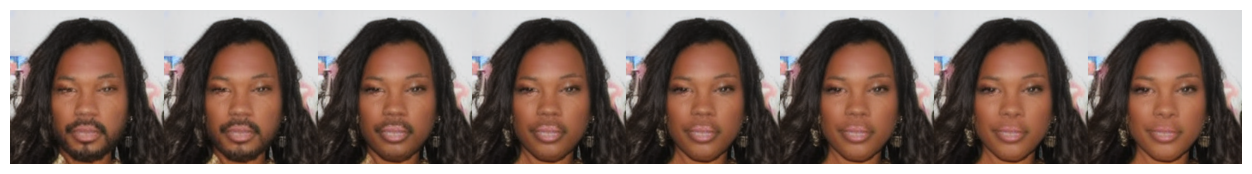

In [154]:
# do intervention (beard, manual seed 10, start from -1, gs lower , more obvious the OOD feature)
inter_id=2
range_len=8
inter_value = torch.from_numpy(np.linspace(-1, 0, num=range_len))
# Do intervention
image_lists = []


noise = torch.randn(1, 4, 32, 32,generator=torch.manual_seed(25)).to(device)
fixed_noise =noise*pipe.scheduler.init_noise_sigma

images = []
#inter_value  = -1   
s_step = 0

for j in range(0,range_len,1):
    interved_image = pipe(
        prompt, 
        num_inference_steps=50, 
        generator=None, 
        image=noise,
        height=256,
        width=256,
        guidance_scale=1.5,
        training=False,
        latents = fixed_noise,
        intervention_indx=inter_id,
        intervention_values=inter_value[j],
        label = torch.tensor([1., 0., 1., 0.]).unsqueeze(0)
    ).images[0]
    image_lists.append(np.asarray(interved_image))
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,range_len),save_path)
